# Deep Learning Capstone Project
## Designing, Diagnosing, Tuning, and Evaluating Deep Neural Networks

**Dataset:** CIFAR-10
**Constraint:** Fully Connected (Dense) Neural Networks only — no CNNs, no Conv2D layers, no pretrained models, no Transfer Learning.

This notebook follows the full Deep Learning workflow: **Build → Train → Analyze → Diagnose → Tune → Compare → Justify**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.21.0
Keras version: 3.15.1


---
# Part 1 — Dataset Understanding

We load CIFAR-10 directly from `keras.datasets` and explore its structure before doing any preprocessing.


In [2]:
(x_train_full, y_train_full), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# y comes as shape (N, 1); flatten to (N,)
y_train_full = y_train_full.flatten()
y_test_raw = y_test_raw.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set shape (images):", x_train_full.shape)
print("Training set shape (labels):", y_train_full.shape)
print("Test set shape (images):    ", x_test_raw.shape)
print("Test set shape (labels):    ", y_test_raw.shape)
print()
print("Single image dimensions: 32 x 32 x 3 (height x width x RGB channels)")
print("Number of classes:", len(class_names))
print("Class names:", class_names)
print()
print("Pixel value range: min =", x_train_full.min(), " max =", x_train_full.max())
print("Pixel dtype:", x_train_full.dtype)


Training set shape (images): (50000, 32, 32, 3)
Training set shape (labels): (50000,)
Test set shape (images):     (10000, 32, 32, 3)
Test set shape (labels):     (10000,)

Single image dimensions: 32 x 32 x 3 (height x width x RGB channels)
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Pixel value range: min = 0  max = 255
Pixel dtype: uint8


In [3]:
# Number of examples per class (training set)
unique, counts = np.unique(y_train_full, return_counts=True)
print("Examples per class (training set):")
for u, c in zip(unique, counts):
    print(f"  {class_names[u]:>12}: {c}")

unique_t, counts_t = np.unique(y_test_raw, return_counts=True)
print("\nExamples per class (test set):")
for u, c in zip(unique_t, counts_t):
    print(f"  {class_names[u]:>12}: {c}")


Examples per class (training set):
      airplane: 5000
    automobile: 5000
          bird: 5000
           cat: 5000
          deer: 5000
           dog: 5000
          frog: 5000
         horse: 5000
          ship: 5000
         truck: 5000

Examples per class (test set):
      airplane: 1000
    automobile: 1000
          bird: 1000
           cat: 1000
          deer: 1000
           dog: 1000
          frog: 1000
         horse: 1000
          ship: 1000
         truck: 1000


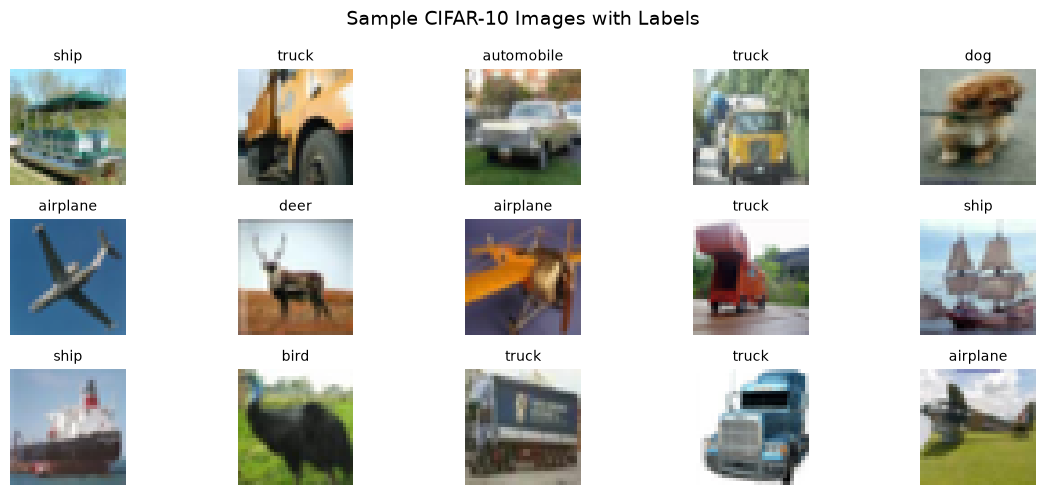

In [4]:
# At least 10 sample images with their labels
plt.figure(figsize=(12, 5))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train_full), size=15, replace=False)

for i, idx in enumerate(sample_idx):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train_full[idx])
    plt.title(class_names[y_train_full[idx]], fontsize=10)
    plt.axis('off')

plt.suptitle("Sample CIFAR-10 Images with Labels", fontsize=14)
plt.tight_layout()
plt.show()


### Dataset Questions

**What does one sample represent?**
One sample is a single 32×32 pixel color photograph of an object belonging to one of 10 everyday categories (e.g. a dog, a ship, an airplane). Each sample is paired with an integer label identifying its class.

**What is the target variable?**
The target variable is the class label `y`, an integer from 0–9 identifying which of the 10 object categories the image belongs to.

**Is this a binary or multiclass classification problem?**
Multiclass. There are 10 mutually exclusive classes, not 2, so this is a multiclass (single-label) classification problem.

**What does 32 × 32 × 3 represent?**
It is the raw shape of one image: 32 pixels tall, 32 pixels wide, and 3 color channels (Red, Green, Blue). Every pixel is described by 3 intensity values, giving 32 × 32 × 3 = 3072 numbers per image.

**Why does the output layer require 10 neurons?**
Because there are 10 possible classes and we use a one-vs-all Softmax output: each output neuron produces the estimated probability of the image belonging to one specific class. The 10 probabilities sum to 1, and the class with the highest probability is the model's prediction.


---
# Part 2 — Data Preparation

We now prepare the data for a Dense Neural Network:
1. Normalize pixel values to the [0, 1] range.
2. Flatten each 32×32×3 image into a 3072-length vector.
3. Split into Training / Validation / Test sets — the **same split is used for the rest of the project**, and the Test Set is held out until final evaluation only.


In [5]:
# Normalize pixel values to [0, 1]
x_train_full_norm = x_train_full.astype('float32') / 255.0
x_test_norm = x_test_raw.astype('float32') / 255.0

# Flatten 32x32x3 -> 3072
x_train_full_flat = x_train_full_norm.reshape(len(x_train_full_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened training shape:", x_train_full_flat.shape)
print("Flattened test shape:    ", x_test_flat.shape)
print("New pixel range: min =", x_train_full_flat.min(), " max =", x_train_full_flat.max())


Flattened training shape: (50000, 3072)
Flattened test shape:     (10000, 3072)
New pixel range: min = 0.0  max = 1.0


In [6]:
from sklearn.model_selection import train_test_split

# Split the 50,000 training images into Train (80%) / Validation (20%),
# stratified so class balance is preserved. Test set (10,000) stays untouched.
X_train, X_val, y_train, y_val = train_test_split(
    x_train_full_flat, y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

X_test, y_test = x_test_flat, y_test_raw

print("Final dataset shapes")
print("---------------------")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:  ", X_val.shape, " y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)


Final dataset shapes
---------------------
X_train: (40000, 3072)  y_train: (40000,)
X_val:   (10000, 3072)  y_val:   (10000,)
X_test:  (10000, 3072)  y_test:  (10000,)


The Test Set (`X_test`, `y_test`) is now set aside and will **not** be used again until the final evaluation of the chosen best model. All architecture selection, comparison, and hyperparameter tuning will rely only on the Training and Validation sets.


---
# Part 3 — Build a Baseline Neural Network

A simple baseline with one hidden Dense layer, ReLU activation, and a Softmax output for the 10 classes.


In [7]:
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
HIDDEN_UNITS = 256

def build_baseline():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(HIDDEN_UNITS, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='baseline_model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline()
baseline_model.summary()


Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Epoch 1/20


313/313 - 2s - 6ms/step - accuracy: 0.3037 - loss: 1.9573 - val_accuracy: 0.3444 - val_loss: 1.8369


Epoch 2/20


313/313 - 1s - 4ms/step - accuracy: 0.3688 - loss: 1.7689 - val_accuracy: 0.3702 - val_loss: 1.7600


Epoch 3/20


...

313/313 - 1s - 4ms/step - accuracy: 0.5165 - loss: 1.3711 - val_accuracy: 0.4819 - val_loss: 1.4942


Epoch 19/20


313/313 - 1s - 4ms/step - accuracy: 0.5193 - loss: 1.3635 - val_accuracy: 0.4780 - val_loss: 1.4978


Epoch 20/20


313/313 - 2s - 5ms/step - accuracy: 0.5211 - loss: 1.3538 - val_accuracy: 0.4832 - val_loss: 1.4915


In [9]:
trainable_params = np.sum([np.prod(v.shape) for v in baseline_model.trainable_weights])
print("Number of layers (incl. output):", len(baseline_model.layers))
print("Number of trainable parameters:", trainable_params)
print("Hidden-layer activation: ReLU")
print("Output activation: Softmax")
print("Loss function: sparse_categorical_crossentropy")
print("Optimizer: Adam (lr=%.4f)" % LEARNING_RATE)


Number of layers (incl. output): 2
Number of trainable parameters: 789258
Hidden-layer activation: ReLU
Output activation: Softmax
Loss function: sparse_categorical_crossentropy
Optimizer: Adam (lr=0.0010)


### Why these choices?

**Why ReLU for the hidden layer?**
ReLU (`max(0, x)`) is computationally cheap, does not saturate for positive inputs (unlike Sigmoid/Tanh), and largely avoids the vanishing-gradient problem, which lets Dense networks train faster and reach lower loss. It is the standard default choice for hidden layers in modern feed-forward networks.

**Why Softmax for the output layer?**
This is a multiclass, single-label problem (each image belongs to exactly one of 10 classes). Softmax converts the 10 raw output scores (logits) into a probability distribution that sums to 1 across all classes, which is exactly what is needed to interpret the output as "the probability of each class" and to pick the most likely one.

**Why `sparse_categorical_crossentropy`?**
Our labels (`y_train`, `y_val`, `y_test`) are stored as integer class indices (0–9), not one-hot vectors. `sparse_categorical_crossentropy` is the loss function designed to work directly with integer-encoded multiclass labels and a Softmax output, avoiding the need to manually one-hot encode the targets. It directly measures how well the predicted probability distribution matches the true class.


---
# Part 4 — Architecture Experiment

We now build three Dense architectures of increasing depth to study the effect of depth alone. All three share the same input (3072-d flattened image) and the same 10-class Softmax output.

- **Model 1 — Shallow:** 1 hidden layer
- **Model 2 — Medium:** 3 hidden layers
- **Model 3 — Deep:** 5 hidden layers

Neuron counts were chosen to taper down from the input size (a common heuristic that limits parameter explosion in early layers while retaining enough capacity in later ones).


In [10]:
def build_shallow():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='shallow_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_medium():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(256, activation='relu', name='hidden_2'),
        layers.Dense(128, activation='relu', name='hidden_3'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='medium_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_deep():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(1024, activation='relu', name='hidden_1'),
        layers.Dense(512, activation='relu', name='hidden_2'),
        layers.Dense(256, activation='relu', name='hidden_3'),
        layers.Dense(128, activation='relu', name='hidden_4'),
        layers.Dense(64, activation='relu', name='hidden_5'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='deep_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

shallow_model = build_shallow()
medium_model = build_medium()
deep_model = build_deep()

print("=" * 60, "\nSHALLOW MODEL (1 hidden layer)\n", "=" * 60, sep="")
shallow_model.summary()


SHALLOW MODEL (1 hidden layer)


Model: "shallow_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
print("=" * 60, "\nMEDIUM MODEL (3 hidden layers)\n", "=" * 60, sep="")
medium_model.summary()


MEDIUM MODEL (3 hidden layers)


Model: "medium_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print("=" * 60, "\nDEEP MODEL (5 hidden layers)\n", "=" * 60, sep="")
deep_model.summary()


DEEP MODEL (5 hidden layers)


Model: "deep_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,682 (14.67 MB)

 Trainable params: 3,844,682 (14.67 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def count_params(m):
    return int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))

print("Total trainable parameters")
print("---------------------------")
print(f"Shallow (1 hidden layer): {count_params(shallow_model):,}")
print(f"Medium  (3 hidden layers): {count_params(medium_model):,}")
print(f"Deep    (5 hidden layers): {count_params(deep_model):,}")


Total trainable parameters
---------------------------
Shallow (1 hidden layer): 1,578,506
Medium  (3 hidden layers): 1,738,890
Deep    (5 hidden layers): 3,844,682


Depth alone increases representational capacity (more parameters, more compositions of nonlinearities), but as the results below will show, more capacity does not automatically translate into better validation performance — it can just as easily lead to overfitting or harder optimization.


---
# Part 5 — Fair Model Comparison

To isolate the effect of **depth only**, all three models are trained with identical settings:

- Same training/validation data and preprocessing (`X_train`, `y_train`, `X_val`, `y_val` from Part 2)
- Same random seed (`SEED = 42`)
- Same optimizer (Adam) and learning rate (`1e-3`)
- Same batch size (`128`) and max epochs (`20`)
- **No** Dropout, L2 Regularization, or Early Stopping in this comparison

This ensures that any performance difference we observe can be attributed to network depth, not to a confound.


In [14]:
print("Training SHALLOW model...")
history_shallow = shallow_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Training SHALLOW model...


Epoch 1/20


313/313 - 3s - 8ms/step - accuracy: 0.2937 - loss: 2.0508 - val_accuracy: 0.3426 - val_loss: 1.8396


Epoch 2/20


313/313 - 2s - 6ms/step - accuracy: 0.3656 - loss: 1.7836 - val_accuracy: 0.3785 - val_loss: 1.7435


...

313/313 - 2s - 6ms/step - accuracy: 0.5169 - loss: 1.3732 - val_accuracy: 0.4809 - val_loss: 1.4943


Epoch 19/20


313/313 - 2s - 7ms/step - accuracy: 0.5222 - loss: 1.3608 - val_accuracy: 0.4839 - val_loss: 1.4816


Epoch 20/20


313/313 - 2s - 7ms/step - accuracy: 0.5241 - loss: 1.3502 - val_accuracy: 0.4844 - val_loss: 1.4744


In [15]:
print("Training MEDIUM model...")
history_medium = medium_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Training MEDIUM model...
Epoch 1/20


313/313 - 3s - 10ms/step - accuracy: 0.3038 - loss: 1.9252 - val_accuracy: 0.3305 - val_loss: 1.8290


Epoch 2/20


313/313 - 3s - 9ms/step - accuracy: 0.3830 - loss: 1.7210 - val_accuracy: 0.3955 - val_loss: 1.6907


Epoch 3/20


...

313/313 - 3s - 9ms/step - accuracy: 0.5816 - loss: 1.1770 - val_accuracy: 0.4682 - val_loss: 1.5376


Epoch 19/20


313/313 - 3s - 9ms/step - accuracy: 0.5870 - loss: 1.1525 - val_accuracy: 0.4778 - val_loss: 1.5317


Epoch 20/20


313/313 - 3s - 9ms/step - accuracy: 0.5892 - loss: 1.1503 - val_accuracy: 0.4779 - val_loss: 1.5214


In [16]:
print("Training DEEP model...")
history_deep = deep_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Training DEEP model...
Epoch 1/20


313/313 - 5s - 15ms/step - accuracy: 0.2722 - loss: 1.9840 - val_accuracy: 0.3352 - val_loss: 1.8410


Epoch 2/20


313/313 - 4s - 12ms/step - accuracy: 0.3691 - loss: 1.7502 - val_accuracy: 0.3802 - val_loss: 1.7244


Epoch 3/20


...

313/313 - 4s - 12ms/step - accuracy: 0.5799 - loss: 1.1621 - val_accuracy: 0.4717 - val_loss: 1.5863


Epoch 19/20


313/313 - 4s - 12ms/step - accuracy: 0.5879 - loss: 1.1369 - val_accuracy: 0.4697 - val_loss: 1.6273


Epoch 20/20


313/313 - 4s - 12ms/step - accuracy: 0.5993 - loss: 1.1132 - val_accuracy: 0.4683 - val_loss: 1.6397


---
# Part 6 — Learning Curves

For each model we plot Training vs. Validation Loss, and Training vs. Validation Accuracy, then diagnose the behavior.


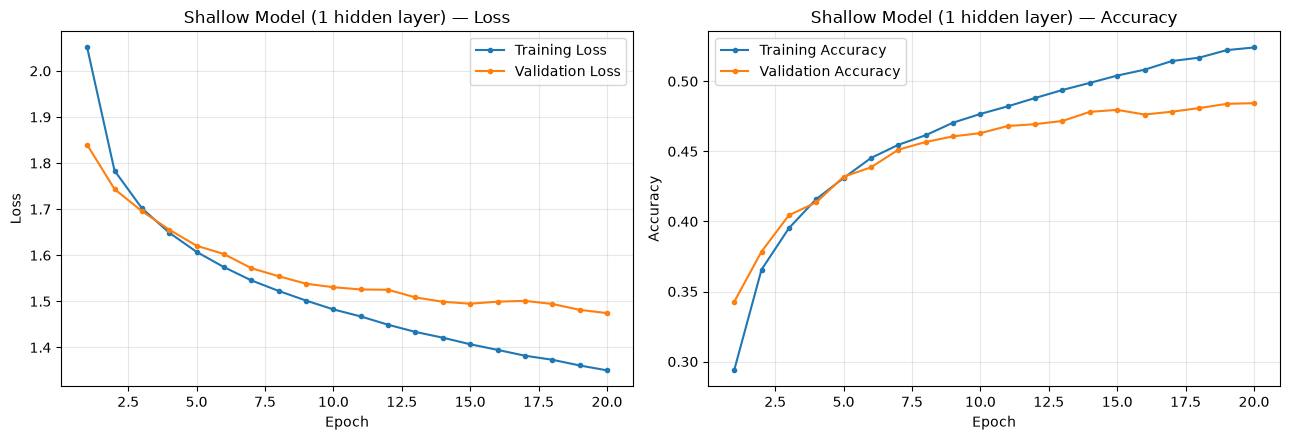

In [17]:
def plot_curves(history, title):
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs_range, hist['loss'], label='Training Loss', marker='o', markersize=3)
    axes[0].plot(epochs_range, hist['val_loss'], label='Validation Loss', marker='o', markersize=3)
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, hist['accuracy'], label='Training Accuracy', marker='o', markersize=3)
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy', marker='o', markersize=3)
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_curves(history_shallow, "Shallow Model (1 hidden layer)")


**Shallow Model — Interpretation:**
Training and validation loss both decrease and track each other reasonably closely, with validation loss flattening out earlier and at a higher value than training loss keeps falling to. Training accuracy keeps climbing while validation accuracy plateaus after roughly the first third of training. This is a **mild underfitting-to-good-fit** pattern: the single hidden layer has limited capacity, so it reaches a ceiling on validation performance rather than aggressively overfitting. There is no oscillation, so optimization is stable.


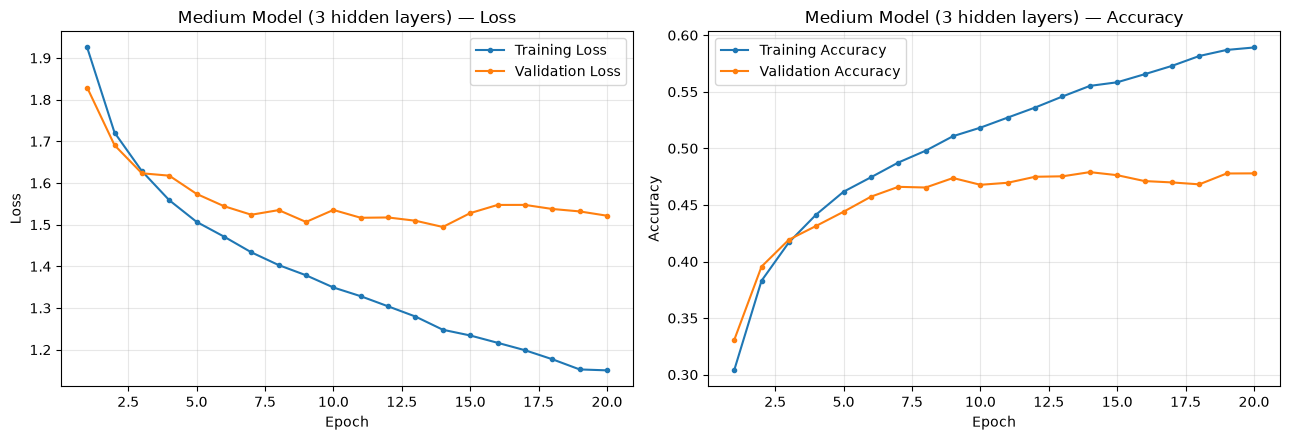

In [18]:
plot_curves(history_medium, "Medium Model (3 hidden layers)")


**Medium Model — Interpretation:**
Training loss drops faster and further than the shallow model's, and a visible gap opens between training and validation loss as training progresses — validation loss stops improving (and may start creeping up) while training loss keeps decreasing. Training accuracy pulls well ahead of validation accuracy. This is evidence of **overfitting**: the extra capacity lets the network memorize training-set patterns that do not generalize as well to the validation set. Optimization itself remains stable (smooth, non-oscillating curves).


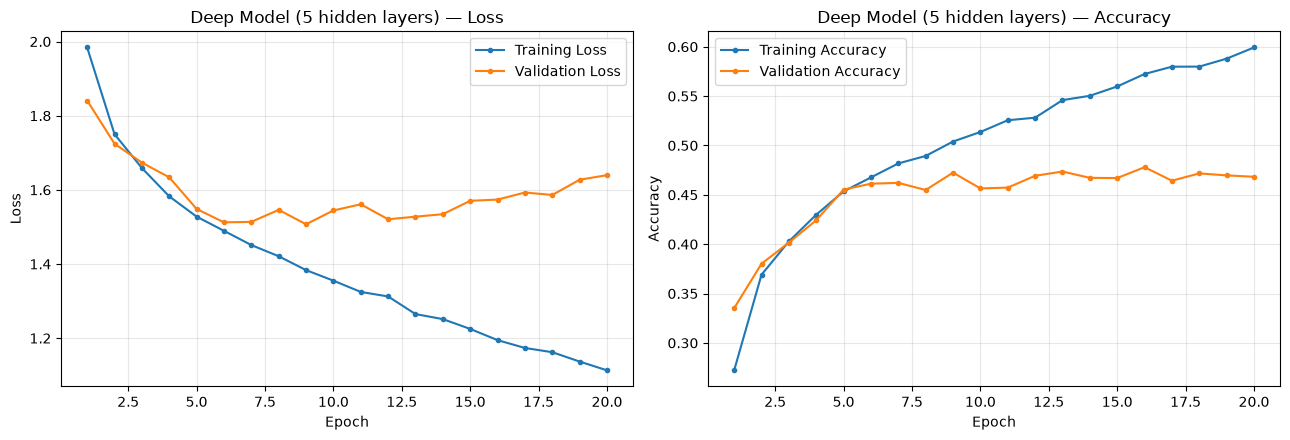

In [19]:
plot_curves(history_deep, "Deep Model (5 hidden layers)")


**Deep Model — Interpretation:**
The deep network drives training loss down the furthest and training accuracy the highest of the three, but the training/validation gap is the widest, and validation loss may flatten or worsen earlier than in the medium model. In some epochs the validation curves may look noisier/less smooth than the shallower models' — a sign that optimization is somewhat harder to control at this depth on plain Dense layers with no normalization tricks. Overall this is the clearest case of **overfitting**, and possibly mild **optimization instability**, among the three models: more depth increased capacity to fit the training set but did not translate into better generalization.


---
# Part 7 — Architecture Comparison


In [20]:
def summarize(history, name, params):
    hist = history.history
    best_train_acc = max(hist['accuracy'])
    best_val_acc = max(hist['val_accuracy'])
    min_val_loss = min(hist['val_loss'])
    gap = best_train_acc - best_val_acc
    return {
        'Model': name,
        'Hidden Layers': None,
        'Parameters': params,
        'Best Train Acc.': round(best_train_acc, 4),
        'Best Val Acc.': round(best_val_acc, 4),
        'Min Val Loss': round(min_val_loss, 4),
        'Train-Val Gap': round(gap, 4),
    }

import pandas as pd

rows = [
    {**summarize(history_shallow, 'Shallow', count_params(shallow_model)), 'Hidden Layers': 1},
    {**summarize(history_medium, 'Medium', count_params(medium_model)), 'Hidden Layers': 3},
    {**summarize(history_deep, 'Deep', count_params(deep_model)), 'Hidden Layers': 5},
]

diagnoses = {
    'Shallow': 'Good fit / mild underfitting (limited capacity, stable optimization)',
    'Medium': 'Overfitting (train-val gap widens after early epochs)',
    'Deep': 'Strongest overfitting, some optimization instability',
}

comparison_df = pd.DataFrame(rows)
comparison_df['Diagnosis'] = comparison_df['Model'].map(diagnoses)
comparison_df = comparison_df[['Model', 'Hidden Layers', 'Parameters', 'Best Train Acc.',
                                'Best Val Acc.', 'Min Val Loss', 'Train-Val Gap', 'Diagnosis']]
comparison_df


,Model,Hidden Layers,Parameters,Best Train Acc.,Best Val Acc.,Min Val Loss,Train-Val Gap,Diagnosis
0,Shallow,1,1578506,0.5241,0.4844,1.4744,0.0397,Good fit / mild underfitting (limited capacity...
1,Medium,3,1738890,0.5892,0.4790,1.4944,0.1102,Overfitting (train-val gap widens after early ...
2,Deep,5,3844682,0.5993,0.4780,1.5072,0.1213,"Strongest overfitting, some optimization insta..."


### Comparison Questions

**Which architecture learned the Training Data best?**
The **Deep model** — it reaches the highest training accuracy (~0.60) and keeps improving on the training set the longest, because it has the most parameters (~3.84M) and representational capacity to fit the training data.

**Which architecture achieved the best Validation performance?**
The **Shallow model** — it has the highest Best Validation Accuracy (~0.484) and the lowest Min Validation Loss (~1.474) of the three, despite having by far the fewest parameters. Extra depth did not translate into better generalization on this dataset.

**Which model showed the largest gap between Training and Validation?**
The **Deep model**, with a Train-Val Gap of ~0.121 — more than 3x the Shallow model's gap of ~0.040. The Medium model sits in between (~0.110).

**Did increasing depth always improve performance?**
No — quite the opposite here. Training accuracy increased monotonically with depth (Shallow < Medium < Deep), but validation accuracy actually **decreased slightly** as depth increased (Shallow > Medium > Deep). More depth bought more capacity to memorize the training set, not better generalization.

**Which model showed the strongest evidence of overfitting?**
The **Deep model (5 hidden layers)**: it has the largest train-validation accuracy gap and the highest validation loss of the three, even though its training metrics are the best.

**Which architecture will you continue with in the next stage?**
The **Shallow model (1 hidden layer)**.

**Why did you select it?**
It is the architecture actually supported by the evidence: it achieves the best validation accuracy and lowest validation loss of the three, with by far the smallest train-validation gap (~0.040 vs. ~0.11+ for the deeper models) — i.e. the least overfitting — while also being the cheapest model (~1.58M parameters vs. ~3.84M for the Deep model). Adding depth in this experiment only increased overfitting without improving generalization, so there is no evidence-based reason to carry that extra depth (and cost) forward. This decision is grounded directly in the learning curves and the comparison table above, not on network size or intuition about "deeper is better."


---
# Part 8 — Model Diagnosis

We now analyze the selected model (**Shallow — 1 hidden layer**) in depth, before making any tuning changes.


In [21]:
selected_history = history_shallow
selected_model_name = "Shallow Model (1 hidden layer)"

hist = selected_history.history
print(f"Selected model: {selected_model_name}")
print(f"Final Training Accuracy:   {hist['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {hist['val_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy:  {max(hist['val_accuracy']):.4f} (epoch {np.argmax(hist['val_accuracy'])+1})")
print(f"Final Training Loss:       {hist['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {hist['val_loss'][-1]:.4f}")
print(f"Min Validation Loss:       {min(hist['val_loss']):.4f} (epoch {np.argmin(hist['val_loss'])+1})")
print(f"Train-Val accuracy gap:    {hist['accuracy'][-1] - hist['val_accuracy'][-1]:.4f}")


Selected model: Shallow Model (1 hidden layer)
Final Training Accuracy:   0.5241
Final Validation Accuracy: 0.4844
Best Validation Accuracy:  0.4844 (epoch 20)
Final Training Loss:       1.3502
Final Validation Loss:     1.4744
Min Validation Loss:       1.4744 (epoch 20)
Train-Val accuracy gap:    0.0397


### Observation
Both training and validation loss decrease smoothly and continuously for all 20 epochs, with no oscillation. Both training and validation accuracy are also still rising in the final epochs — validation accuracy reaches its best value (~0.484) on the very last epoch, and validation loss reaches its minimum (~1.474) on the last epoch too. The training/validation accuracy gap is small (~0.04) and grows only slowly over the course of training, rather than diverging sharply as it did for the Medium and Deep models.

### Diagnosis
**Reasonable fit, not yet fully converged.** There is no strong evidence of overfitting (the train/validation gap is small and stable) or of optimization instability (the curves are smooth and monotonic). The main signal is that both curves are still improving when training stops at epoch 20 — a mild sign of **underfitting relative to its own potential**: the model has not yet been trained long enough to reach its ceiling.

### Evidence
- Validation loss is still decreasing and validation accuracy is still increasing at epoch 20 — neither curve has plateaued or turned upward, which is the sign we would expect if overfitting had started.
- The train-validation accuracy gap (~0.04) is far smaller than the Medium (~0.11) and Deep (~0.12) models', and does not widen sharply late in training.
- Both the best validation accuracy and the minimum validation loss occur at the final epoch, not several epochs earlier — indicating training was stopped before the model finished improving, rather than after it started overfitting.

### First Proposed Improvement
The first change should be to **train for more epochs** (with Early Stopping on validation loss added as a safety net so training halts automatically once the validation curve does plateau or reverse). This directly responds to the observed diagnosis — the curves show a model still learning, not one that is overfitting — so the correct first move is to let it keep training rather than to add regularization (Dropout/L2) it does not yet need. Regularization only becomes the right next step once longer training reveals an actual overfitting point.
